In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
Path("../reports/eda").mkdir(parents=True, exist_ok=True)
df = pd.read_csv("../data/creditcard.csv")
df.shape

(284807, 31)

## 1. Taux de fraude

Class
0    284315
1       492
Name: count, dtype: int64 0.001727485630620034
Class
0    22.00
1     9.25
Name: Amount, dtype: float64


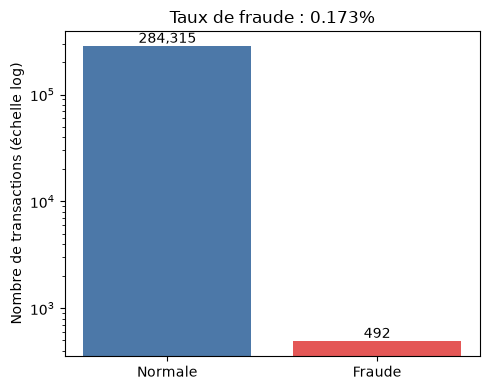

In [2]:
print(df["Class"].value_counts(), df["Class"].mean())
print(df.groupby("Class")["Amount"].median())
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Class"].value_counts()
ax.bar(["Normale", "Fraude"], counts.values, color=["#4c78a8", "#e45756"])
ax.set_yscale("log"); ax.set_ylabel("Nombre de transactions (échelle log)")
for i, v in enumerate(counts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title(f"Taux de fraude : {df['Class'].mean():.3%}")
fig.tight_layout(); fig.savefig("../reports/eda/01_fraud_rate.png", dpi=120)

## 2. Montant selon la classe

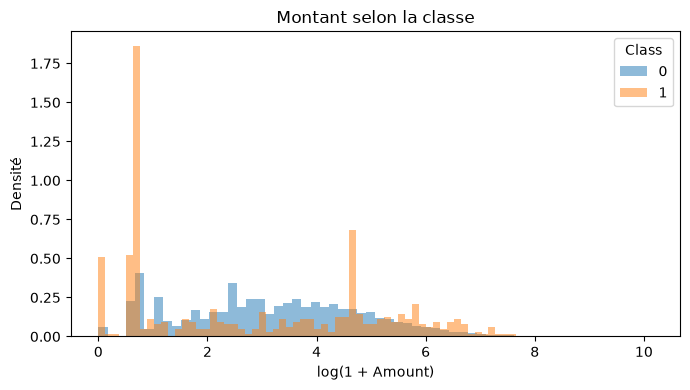

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
for cls in [0, 1]:
    ax.hist(np.log1p(df.loc[df["Class"] == cls, "Amount"]), bins=60,
            density=True, alpha=0.5, label=str(cls))
ax.legend(title="Class"); ax.set_xlabel("log(1 + Amount)"); ax.set_ylabel("Densité")
ax.set_title("Montant selon la classe")
fig.tight_layout(); fig.savefig("../reports/eda/02_amount_by_class.png", dpi=120)

## 3. Fraudes par heure

nuit (1h-5h) : 0.73% | jour (9h-21h) : 0.14%


,sum,mean
hour,,
0.0,6,0.000780
1.0,10,0.002370
2.0,57,0.017127
3.0,17,0.004868
4.0,23,0.010412
5.0,11,0.003679
6.0,9,0.002195
7.0,23,0.003175
8.0,9,0.000876


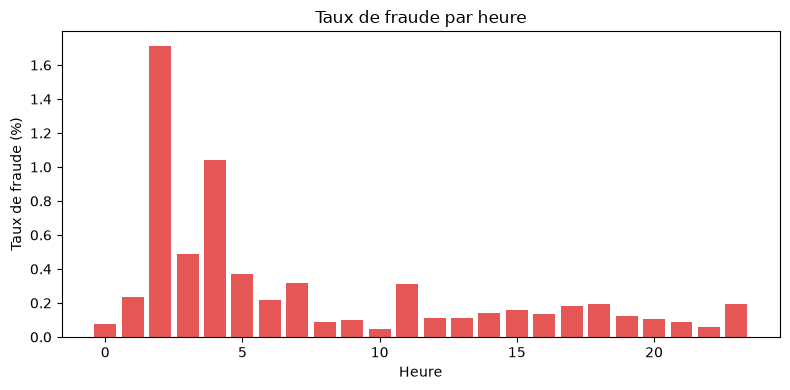

In [4]:
df["hour"] = (df["Time"] // 3600) % 24
by_hour = df.groupby("hour")["Class"].agg(["sum", "mean"])
night = df[df["hour"].between(1, 5)]["Class"].mean()
day = df[df["hour"].between(9, 21)]["Class"].mean()
print(f"nuit (1h-5h) : {night:.2%} | jour (9h-21h) : {day:.2%}")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_hour.index, by_hour["mean"] * 100, color="#e45756")
ax.set_xlabel("Heure"); ax.set_ylabel("Taux de fraude (%)")
ax.set_title("Taux de fraude par heure")
fig.tight_layout(); fig.savefig("../reports/eda/03_fraud_by_hour.png", dpi=120)
by_hour

## Conclusions
1. **Déséquilibre extrême** : 492 fraudes sur 284 807 transactions (0,173 %). L'accuracy est inutile (« toujours normal » = 99,8 %), on mesure le PR-AUC.
2. **Montants** : le montant médian d'une fraude (9,25) est plus bas que celui d'une transaction normale (22,00). Les fraudes sont souvent de petits montants, donc `log(1 + Amount)` est la bonne échelle.
3. **Heures** : le taux de fraude est d'environ 0,73 % la nuit (1 h à 5 h) contre 0,14 % en journée (9 h à 21 h) : il y a peu de transactions la nuit mais autant de fraudes. `hour` est une feature utile.